In [ ]:
import pandas as pd

#criar uma tabela estruturada chamada DataFrame contendo esses dados

sales = pd.DataFrame(
    {
        "product": ["Caneca", "Camiseta", "Caneca", "Adesivo", "Camiseta"],
        "quantity": [2, 1, 4, 10, 3],
        "unit_price": [35.0, 79.9, 35.0, 5.5, 79.9],
        "country": ["Brasil", "Brasil", "Portugal", "Brasil", "Argentina"],
    }
)

sales

,product,quantity,unit_price,country
0,Caneca,2,35.0,Brasil
1,Camiseta,1,79.9,Brasil
2,Caneca,4,35.0,Portugal
3,Adesivo,10,5.5,Brasil
4,Camiseta,3,79.9,Argentina


In [ ]:
#Ver somente os valores unitarios

sales["unit_price"]

0    35.0
1    79.9
2    35.0
3     5.5
4    79.9
Name: unit_price, dtype: float64

In [4]:
#Criar nova coluna de receita (unitario * total)

sales["revenue"] = sales["quantity"] * sales["unit_price"]
sales

,product,quantity,unit_price,country,revenue
0,Caneca,2,35.0,Brasil,70.0
1,Camiseta,1,79.9,Brasil,79.9
2,Caneca,4,35.0,Portugal,140.0
3,Adesivo,10,5.5,Brasil,55.0
4,Camiseta,3,79.9,Argentina,239.7


In [ ]:
#crir um filtro das vendas por paises, cujo o valor seja "brasil"
brazil_filter = sales["country"].eq("Brasil")
#print(brazil_filter)

0     True
1     True
2    False
3     True
4    False
Name: country, dtype: bool


In [7]:
#aplicar o filtro
sales.loc[brazil_filter]

,product,quantity,unit_price,country,revenue
0,Caneca,2,35.0,Brasil,70.0
1,Camiseta,1,79.9,Brasil,79.9
3,Adesivo,10,5.5,Brasil,55.0


In [8]:
#criar filtro de alto faturamento (maior que 50)

high_revenue_filter = sales["revenue"].gt(50)

In [9]:
#combinando os filtros de alto faturamento e pais

sales.loc[brazil_filter & high_revenue_filter]

,product,quantity,unit_price,country,revenue
0,Caneca,2,35.0,Brasil,70.0
1,Camiseta,1,79.9,Brasil,79.9
3,Adesivo,10,5.5,Brasil,55.0


In [10]:
#resumo estatístico (quartis) describe exibe as 8 principais estatisticas descritivas

sales.describe().round(2)

,quantity,unit_price,revenue
count,5.00,5.00,5.00
mean,4.00,47.06,116.92
std,3.54,32.31,75.85
min,1.00,5.50,55.00
25%,2.00,35.00,70.00
50%,3.00,35.00,79.90
75%,4.00,79.90,140.00
max,10.00,79.90,239.70


In [12]:
#importar matplolib para gerar graficos

import matplotlib.pyplot as plt

In [13]:
#isolar (selecionar) as estatísticas de interesse da coluna desejada (revenue)

stats = sales["revenue"].describe()[["mean", "std", "25%", "50%", "75%"]]

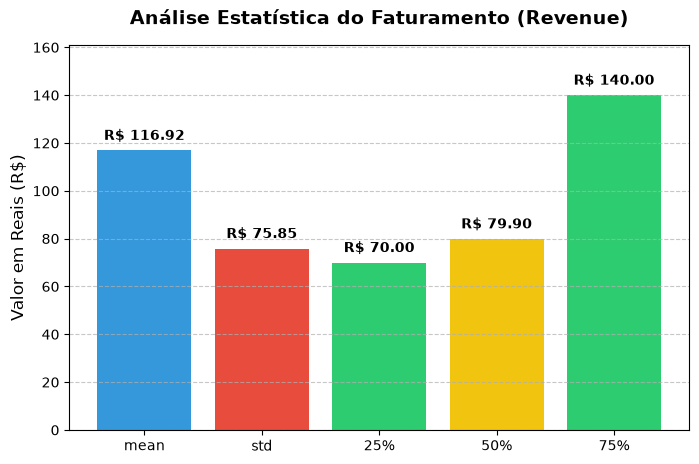

In [16]:
#criar o gráfico de barras

#figure = figura vazia na tela
#figsixe = tamanho da figura em polegadas (largura e altura)
plt.figure(figsize=(8, 5))

#plt.bar = gera as barras verticais
#stats.index = eixo x (nomes das estatiticas)
#status.value = eixo y (valores)
bars = plt.bar(stats.index, stats.values, color=["#3498db", "#e74c3c", "#2ecc71", "#f1c40f", "#2ecc71"])


#adicionar os valores exatos

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'R$ {height:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
    

# 4. Configurações visuais do gráfico
plt.title("Análise Estatística do Faturamento (Revenue)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Valor em Reais (R$)", fontsize=12)
plt.ylim(0, max(stats.values) * 1.15)  # Dá um espaço no topo para os textos
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Exibe o gráfico na tela
plt.show()    

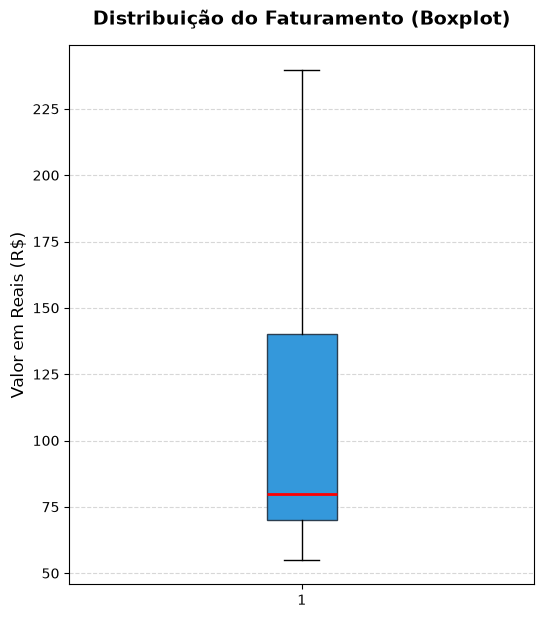

In [18]:
#criando um gráfico de boxplot

# 2. Criando a área do gráfico
plt.figure(figsize=(6, 7))

# 3. Desenhando o Boxplot
# patch_artist=True permite pintar o interior da caixa
box = plt.boxplot(sales["revenue"], 
                  patch_artist=True,
                  #labels=["Faturamento por Pedido"],
                  medianprops={"color": "red", "linewidth": 2}, # Linha da mediana em vermelho
                  boxprops={"facecolor": "#3498db", "color": "#2c3e50"}, # Caixa azul
                  flierprops={"marker": "o", "markerfacecolor": "orange", "markersize": 8}) # Outliers em laranja

# 4. Customização visual
plt.title("Distribuição do Faturamento (Boxplot)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Valor em Reais (R$)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Exibe o gráfico
plt.show()

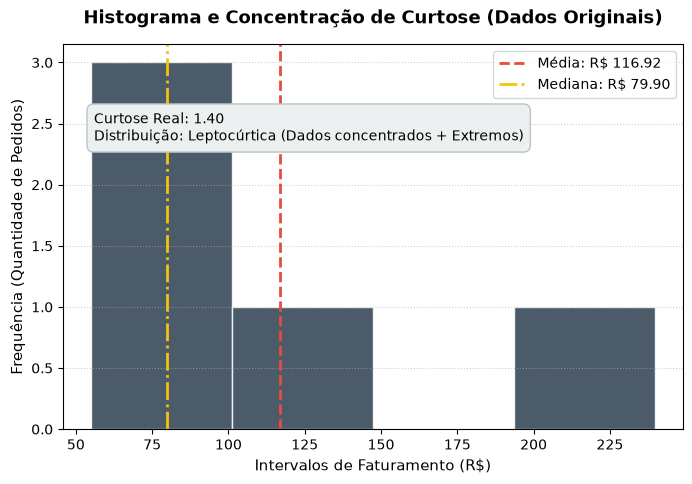

In [20]:
#Analisar a distribuição de faturamento  (curtose)

# 1. Calculamos a curtose diretamente da nossa coluna original 'revenue'
kurtosis_value = sales["revenue"].kurt()

# 2. Criamos a área do gráfico
plt.figure(figsize=(8, 5))

# 3. Desenhamos o Histograma clássico com os nossos 5 dados originais
# bins=4 separa os valores em fatias para vermos a contagem/concentração
plt.hist(sales["revenue"], bins=4, color="#2c3e50", edgecolor="white", alpha=0.85)

# 4. Adicionamos a linha da Média e da Mediana para contexto
plt.axvline(sales["revenue"].mean(), color="#e74c3c", linestyle="--", linewidth=2, label=f"Média: R$ {sales['revenue'].mean():.2f}")
plt.axvline(sales["revenue"].median(), color="#f1c40f", linestyle="-.", linewidth=2, label=f"Mediana: R$ {sales['revenue'].median():.2f}")

# 5. Texto explicativo simples baseado nos seus dados reais
tipo_curtose = "Leptocúrtica (Dados concentrados + Extremos)" if kurtosis_value > 0 else "Platicúrtica (Dados espalhados)"
texto_info = f"Curtose Real: {kurtosis_value:.2f}\nDistribuição: {tipo_curtose}"

plt.text(0.05, 0.75, texto_info, transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#ecf0f1", edgecolor="#bdc3c7"))

# 6. Ajustes visuais finais
plt.title("Histograma e Concentração de Curtose (Dados Originais)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Intervalos de Faturamento (R$)", fontsize=11)
plt.ylabel("Frequência (Quantidade de Pedidos)", fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()

# 7. Exibe o gráfico sem erros
plt.show()